"""
Make sure to include the course name, assignment number, your name and entry number and date
on the top of report. Moreover, in the code include your name and entry number and provide
comments.
"""
COURSE NAME: Biomedical Signal and Image Processing(BML7350)
ASSIGNMENT NUMBER: 1
NAME: Angom Umakanta Singh
ENTRY NUMBER: EEZ258518
DATE: 12th February 2026

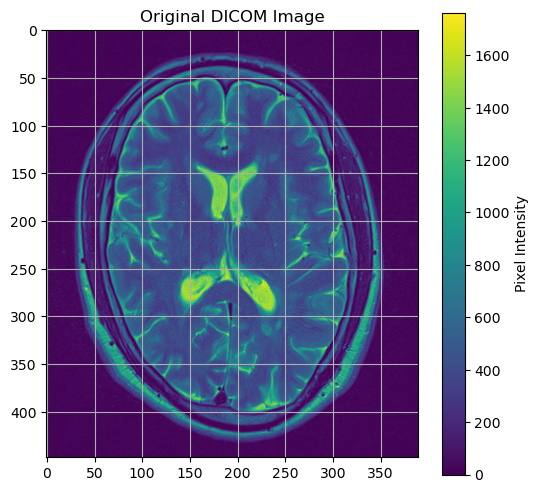

ROI is a 50 x 50 pixel
Gray Matter : (130,61)
White Matter : (130,200)
Background : (5,5)


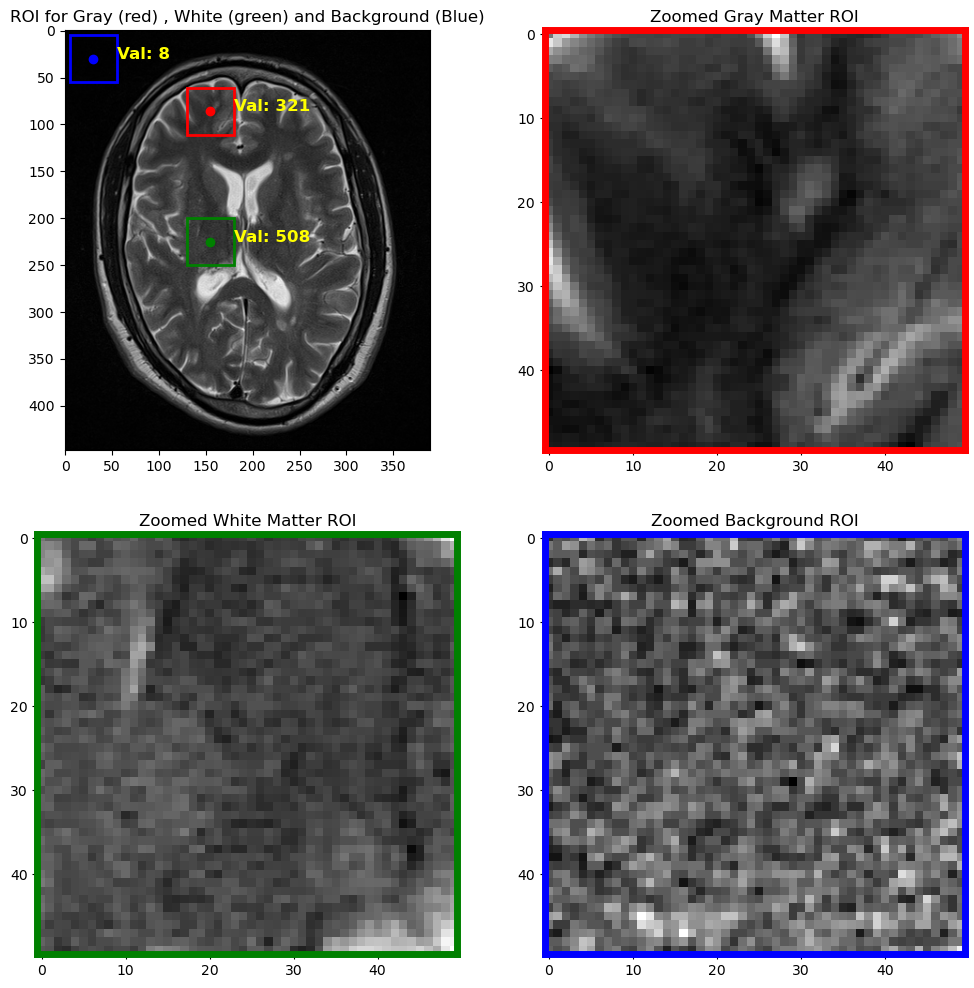

SNR of Gray Matter: 80.88283377864533
SNR of White Matter: 71.87532213977708


In [1]:
"""
1) Compute SNR of the image in gray matter and white matter regions. Show the location of
ROIs used for computing SNR. Use formula: SNR = [mean of SI(ROI_GM)]/[SD of SI
in background]. ROIs in foreground and background should be of similar sizes.
"""


#libraries
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
dataset = pydicom.dcmread('T2W-MRI.dcm')

# Extract the raw pixel data
image = dataset.pixel_array

# Visualize
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original DICOM Image")
plt.colorbar(label="Pixel Intensity")
plt.grid('true')
plt.show()

# Define the ROI coordinates (The Box)

# Gray Matter ROI
y1, y2 = 61, 111
x1, x2 = 130, 180

# White Matter ROI
y3, y4 = 200, 250
x3, x4 = 130, 180

# Background ROI for noise calculation
y5, y6 = 5, 55
x5, x6 = 5, 55
print("ROI is a 50 x 50 pixel")
print(f"Gray Matter : ({x1},{y1})")
print(f"White Matter : ({x3},{y3})")
print(f"Background : ({x5},{y5})")

# 2. Define the specific Pixel to measure
# Gray
px, py = x1+(x2-x1)//2, y1+(y2-y1)//2
pixel_value = image[py, px]

# White
w_px, w_py = x3+(x4-x3)//2, y3+(y4-y3)//2
w_pixel_value = image[w_px,w_py]
 
# Background
b_px, b_py = x5+(x6-x5)//2, y5+(y6-y5)//2
b_pixel_value = image[b_px, b_py]

# Create the ROI crop
roi = image[y1:y2, x1:x2] # gray
w_roi = image[y3:y4, x3:x4] # white
b_roi = image[y5:y6, x5:x6]

# Visualization
plt.figure(figsize=(12, 12))

# --- Left Plot: Original Image ---
plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("ROI for Gray (red) , White (green) and Background (Blue)")
#plt.axis('off')

# Draw the Red Box
rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none')
plt.gca().add_patch(rect)

# Draw the Green Box
w_rect = patches.Rectangle((x3,y3), x4-x3,y4-y3,linewidth=2, edgecolor='green', facecolor='none')
plt.gca().add_patch(w_rect)

# Draw the Blue Box
b_rect = patches.Rectangle((x5,y5), x6-x5, y6-y5, linewidth=2, edgecolor='blue', facecolor='none')
plt.gca().add_patch(b_rect)


#Gray Matter - Draw the Pointer (Red Dot)
plt.plot(px, py, 'ro') # 'r' = red, 'o' = circle marker
# Write the text next to the dot
plt.text(px + 25, py, f"Val: {pixel_value}", color='yellow', fontsize=12, weight='bold')
# White Matter - Draw Green Pointer
plt.plot(w_px,w_py,'go')
plt.text(w_px + 25, w_py, f"Val: {w_pixel_value}", color='yellow', fontsize=12, weight='bold')
# Background - Blue dot
plt.plot(b_px,b_py,'bo')
plt.text(b_px + 25, b_py, f"Val: {b_pixel_value}", color='yellow', fontsize=12, weight='bold')

# Gray Matter ROI Plot
plt.subplot(2, 2, 2)
border_thickness = 5
plt.imshow(roi, cmap='gray')
plt.title("Zoomed Gray Matter ROI")
for spine in plt.gca().spines.values():
    spine.set_edgecolor('red')
    spine.set_linewidth(border_thickness)
#plt.axis('off')
# White Matter ROI Plot
plt.subplot(2,2,3)
plt.imshow(w_roi, cmap='gray')
plt.title("Zoomed White Matter ROI")
for spine in plt.gca().spines.values():
    spine.set_edgecolor('green')
    spine.set_linewidth(border_thickness)
# Background ROI Plot
plt.subplot(2,2,4)
plt.imshow(b_roi, cmap='gray')
plt.title("Zoomed Background ROI")
for spine in plt.gca().spines.values():
    spine.set_edgecolor('blue')
    spine.set_linewidth(border_thickness)
plt.show()

gray_float = roi.astype(np.float64)
gray_mean = np.mean(gray_float, dtype=np.float64)
white_float = w_roi.astype(np.float64)
white_mean = np.mean(white_float, dtype=np.float64)
background_float = b_roi.astype(np.float64)
background_std = np.std(background_float, dtype=np.float64)

SNR_gray = gray_mean / background_std
SNR_white = white_mean / background_std

print(f"SNR of Gray Matter: {SNR_gray}")
print(f"SNR of White Matter: {SNR_white}")

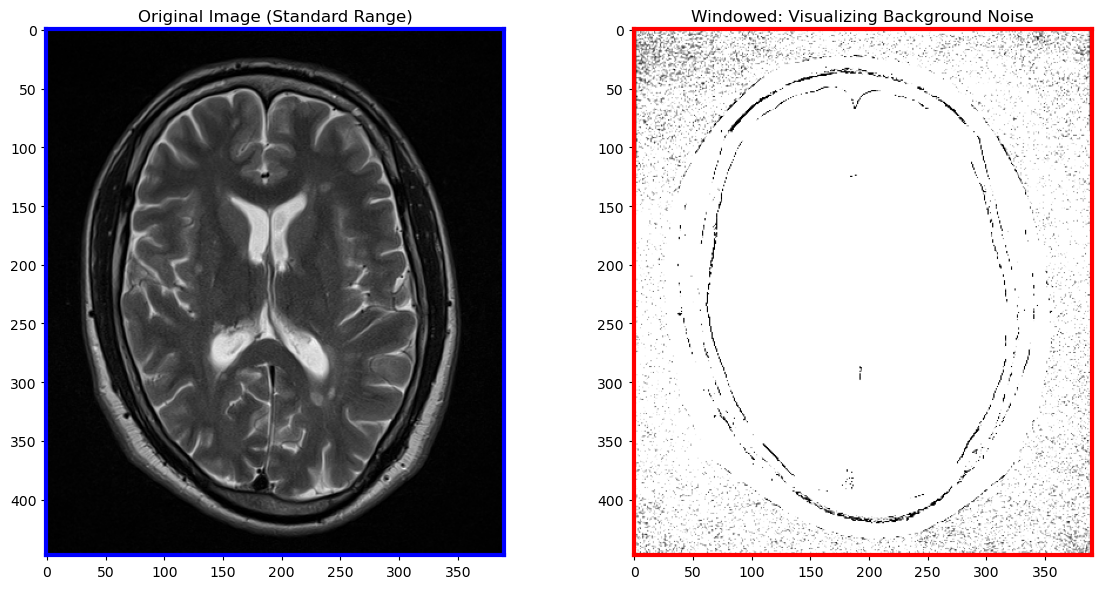

In [2]:
"""
2) Adjust intensity range of the image intensity (windowing) for visualizing background
noise. (Put original image and image showing noise)
"""

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Original Image
img = image
ax1.imshow(img, cmap='gray')
ax1.set_title("Original Image (Standard Range)")

# Subplot 2: Windowed Image to show Noise
# We set vmax to a very low value to "blow out" the signal and see the dark areas
noise_ceiling = np.percentile(img, 10) # Look at the bottom 10% of intensities
ax2.imshow(img, cmap='gray', vmin=0, vmax=noise_ceiling)
ax2.set_title("Windowed: Visualizing Background Noise")

# Adding the thick colored borders from before
for ax, color in zip([ax1, ax2], ['blue', 'red']):
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.tight_layout()
plt.show()


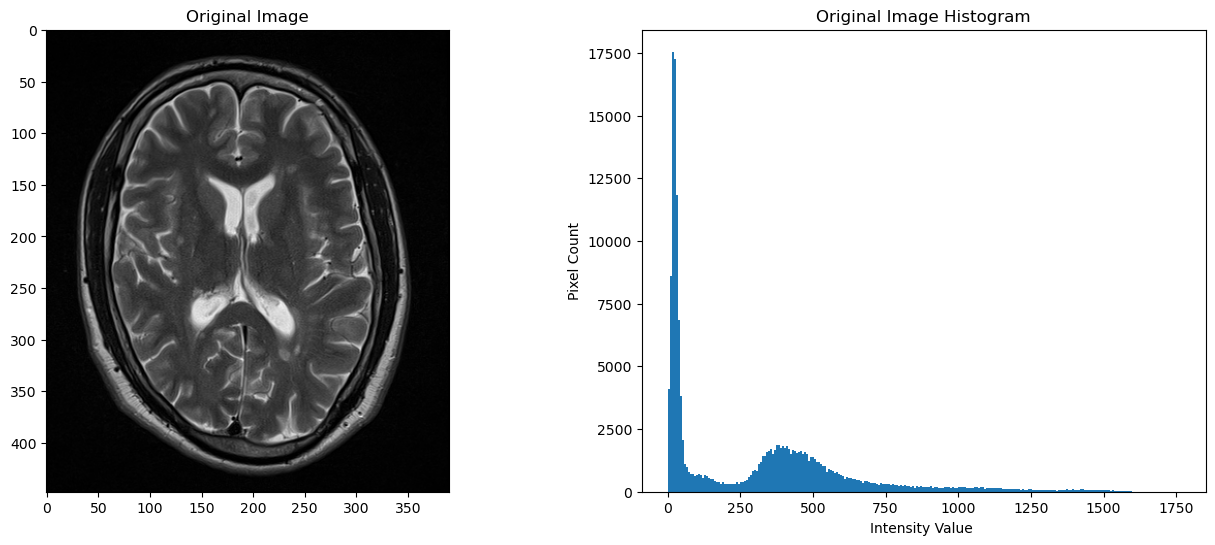

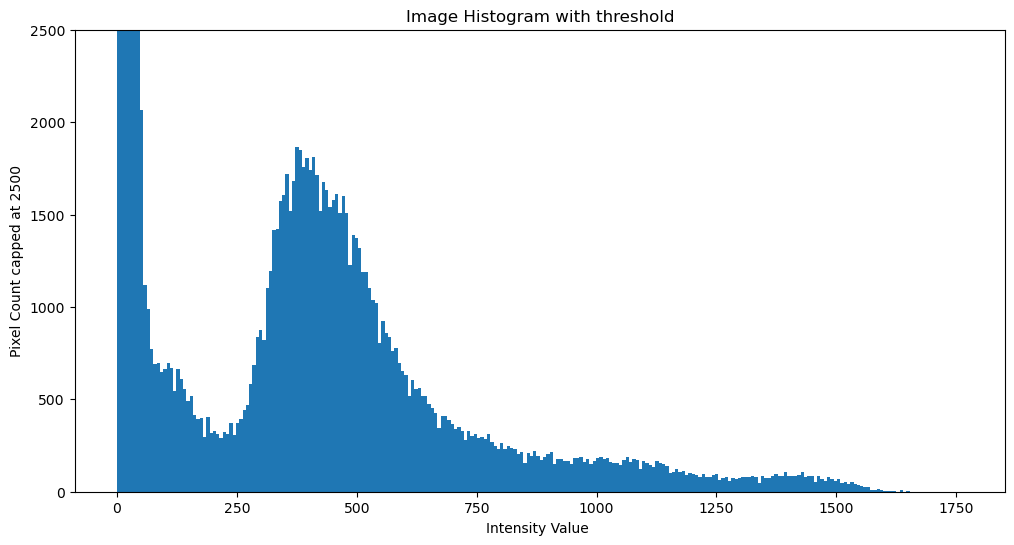

In [3]:
"""
3) Compute histogram of intensity values in the background. (Use appropriate threshold to
get values in the background. Draw inferences from histogram.
"""


# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Display original image
ax1.imshow(image, cmap='gray')
ax1.set_title("Original Image")

# 2. Display original image histogram
# .ravel() flattens the 2D image into 1D for the histogram
hist_image = image.ravel()
#ax2.set_ylim(0,2500)
ax2.hist(hist_image, bins=256)
ax2.set_title("Original Image Histogram")
ax2.set_xlabel("Intensity Value ")
ax2.set_ylabel("Pixel Count")
plt.show()

threshold = 2500
plt.figure(figsize=(12, 6))
plt.ylim(0,threshold)
plt.hist(hist_image, bins=256)
plt.title("Image Histogram with threshold")
plt.xlabel("Intensity Value ")
plt.ylabel(f"Pixel Count capped at {threshold}")
plt.show()





ORIGINAL:
SNR of Gray Matter: 80.88283377864533
SNR of White Matter: 71.87532213977708

MEAN FILTER (uniform):
SNR of Gray Matter: 139.24419226466645
SNR of White Matter: 123.88620715239439

MEAN FILTER (Kernel 2D Convolution):
SNR of Gray Matter: 140.01332398890207
SNR of White Matter: 124.5925899985389

MEDIAN FILTER (Kernel 2D Convolution):
SNR of Gray Matter: 130.5376799349945
SNR of White Matter: 116.42194247152321


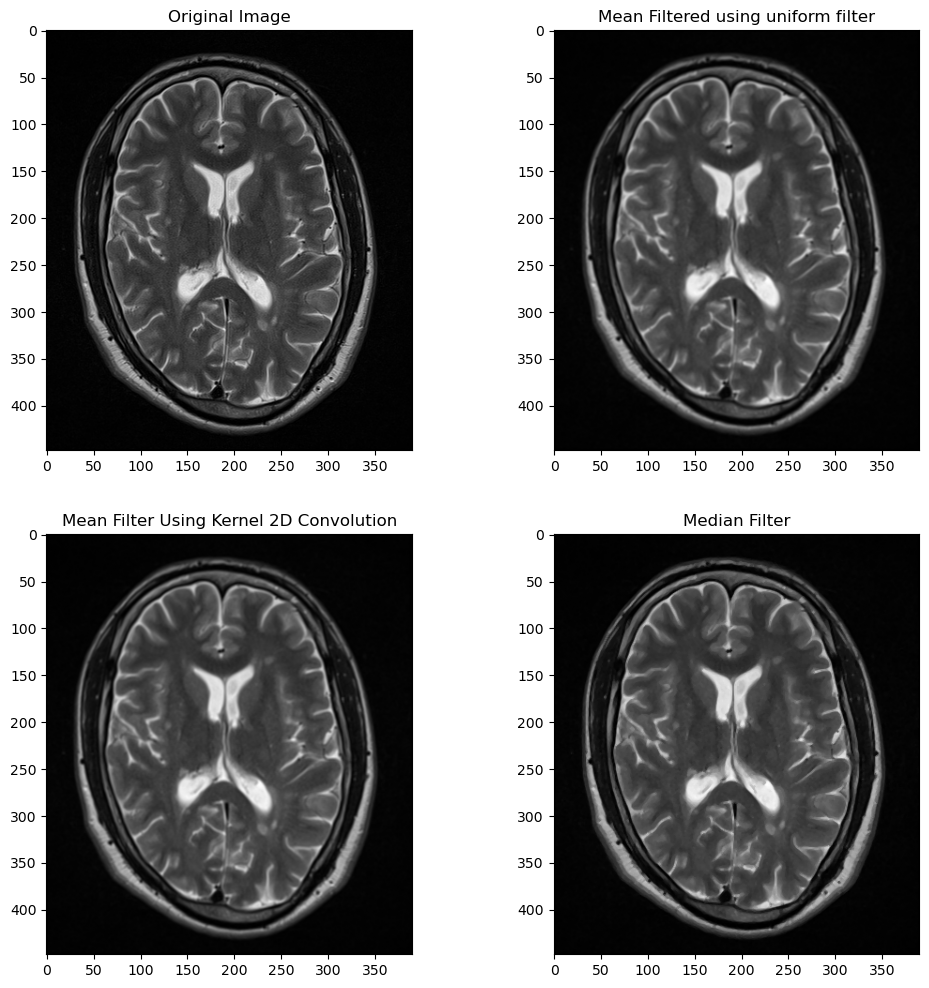

In [4]:
"""
4) Apply mean filter and Gaussian filter and compare SNR before and after filtering.

"""

from scipy import ndimage, signal
from scipy.ndimage import uniform_filter, median_filter

img = image

# ===== MEAN FILTER (3x3) =====
# Method 1a: uniform_filter (fastest)
mean_filtered = ndimage.uniform_filter(img, size=3)

# Method 1b: convolve with ones kernel
kernel = np.ones((3, 3)) / 9
mean_filtered2 = signal.convolve2d(img, kernel, mode='same')

# ===== MEDIAN FILTER (3x3) =====
median_filtered = ndimage.median_filter(img, size=3)

plt.figure(figsize=(12, 12))

# --- Left Plot: Original Image ---
plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")

plt.subplot(2,2,2)
plt.imshow(mean_filtered,cmap='gray')
plt.title("Mean Filtered using uniform filter")

plt.subplot(2,2,3)
plt.imshow(mean_filtered2,cmap='gray')
plt.title("Mean Filter Using Kernel 2D Convolution")

plt.subplot(2,2,4)
plt.imshow(median_filtered,cmap='gray')
plt.title("Median Filter")

# SNR :
# Original Image: ( Results from Question 1)
SNR_gray = gray_mean / background_std
SNR_white = white_mean / background_std
print("ORIGINAL:")
print(f"SNR of Gray Matter: {SNR_gray}")
print(f"SNR of White Matter: {SNR_white}")

# Mean_filtered Image: 
# Create the ROI crop
mf_roi = mean_filtered[y1:y2, x1:x2] # gray
mf_w_roi = mean_filtered[y3:y4, x3:x4] # white
mf_b_roi = mean_filtered[y5:y6, x5:x6] # background

mf_gray_float = mf_roi.astype(np.float64)
mf_gray_mean = np.mean(mf_gray_float, dtype=np.float64)
mf_white_float = mf_w_roi.astype(np.float64)
mf_white_mean = np.mean(mf_white_float, dtype=np.float64)
mf_background_float = mf_b_roi.astype(np.float64)
mf_background_std = np.std(mf_background_float, dtype=np.float64)

mf_SNR_gray = mf_gray_mean / mf_background_std
mf_SNR_white = mf_white_mean / mf_background_std
print("\nMEAN FILTER (uniform):")
print(f"SNR of Gray Matter: {mf_SNR_gray}")
print(f"SNR of White Matter: {mf_SNR_white}")

# Kernel Convolution Mean_filtered Image: 
# Create the ROI crop
mf_roi = mean_filtered2[y1:y2, x1:x2] # gray
mf_w_roi = mean_filtered2[y3:y4, x3:x4] # white
mf_b_roi = mean_filtered2[y5:y6, x5:x6] # background

mf_gray_float = mf_roi.astype(np.float64)
mf_gray_mean = np.mean(mf_gray_float, dtype=np.float64)
mf_white_float = mf_w_roi.astype(np.float64)
mf_white_mean = np.mean(mf_white_float, dtype=np.float64)
mf_background_float = mf_b_roi.astype(np.float64)
mf_background_std = np.std(mf_background_float, dtype=np.float64)

mf_SNR_gray = mf_gray_mean / mf_background_std
mf_SNR_white = mf_white_mean / mf_background_std
print("\nMEAN FILTER (Kernel 2D Convolution):")
print(f"SNR of Gray Matter: {mf_SNR_gray}")
print(f"SNR of White Matter: {mf_SNR_white}")

# Median_filtered Image: 
# Create the ROI crop
mdf_roi = median_filtered[y1:y2, x1:x2] # gray
mdf_w_roi = median_filtered[y3:y4, x3:x4] # white
mdf_b_roi = median_filtered[y5:y6, x5:x6] # background

mdf_gray_float = mdf_roi.astype(np.float64)
mdf_gray_mean = np.mean(mdf_gray_float, dtype=np.float64)
mdf_white_float = mdf_w_roi.astype(np.float64)
mdf_white_mean = np.mean(mdf_white_float, dtype=np.float64)
mdf_background_float = mdf_b_roi.astype(np.float64)
mdf_background_std = np.std(mdf_background_float, dtype=np.float64)

mdf_SNR_gray = mdf_gray_mean / mdf_background_std
mdf_SNR_white = mdf_white_mean / mdf_background_std
print("\nMEDIAN FILTER (Kernel 2D Convolution):")
print(f"SNR of Gray Matter: {mdf_SNR_gray}")
print(f"SNR of White Matter: {mdf_SNR_white}")
    



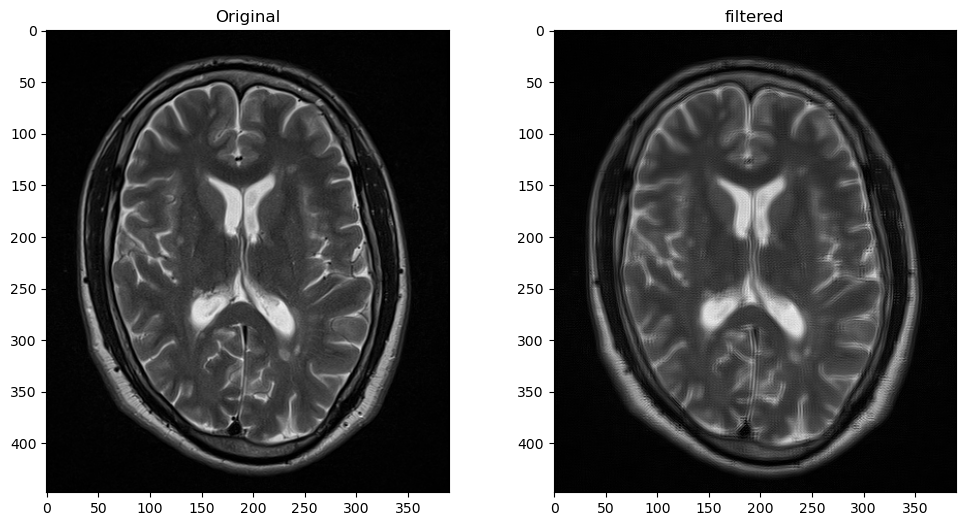

In [5]:
"""
5) Apply mean filter (3 by 3 kernel size) using Fourier transform operation (based on
convolution theorem)
"""
from scipy.fft import fft2,ifft2

img_array = np.array(image, dtype=np.float32)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_array, cmap='gray')
plt.title("Original")
#plt.show()
# Pad with zeros on all sides
#img_array = np.pad(img_array, pad_width=1, mode='constant', constant_values=0)

# Perform 2D FFT
fft_image = np.fft.fft2(img_array)

# Shift zero frequency component to center
fft_shifted = np.fft.fftshift(fft_image)

# ones kernel
kernel = np.ones((3, 3), dtype=np.float32) / 9
# Pad with zeros on all sides
kernel = np.pad(kernel, pad_width=1, mode='constant', constant_values=0)
# 2. Compute FFT of the kernel, PADDING IT to the image's shape
# The 's' parameter automatically pads with zeros
fft_kernel = np.fft.fft2(kernel, s=fft_shifted.shape)
# Perform 2D FFT
#fft_kernel = np.fft.fft2(kernel)
# point wise Multiplication
f_product = fft_shifted * fft_kernel
# inverse fft
filtered = np.fft.ifft2(f_product)
f_img = np.abs(filtered)
plt.subplot(1,2,2)
plt.imshow(f_img,cmap='gray')
plt.title("filtered")
plt.show()







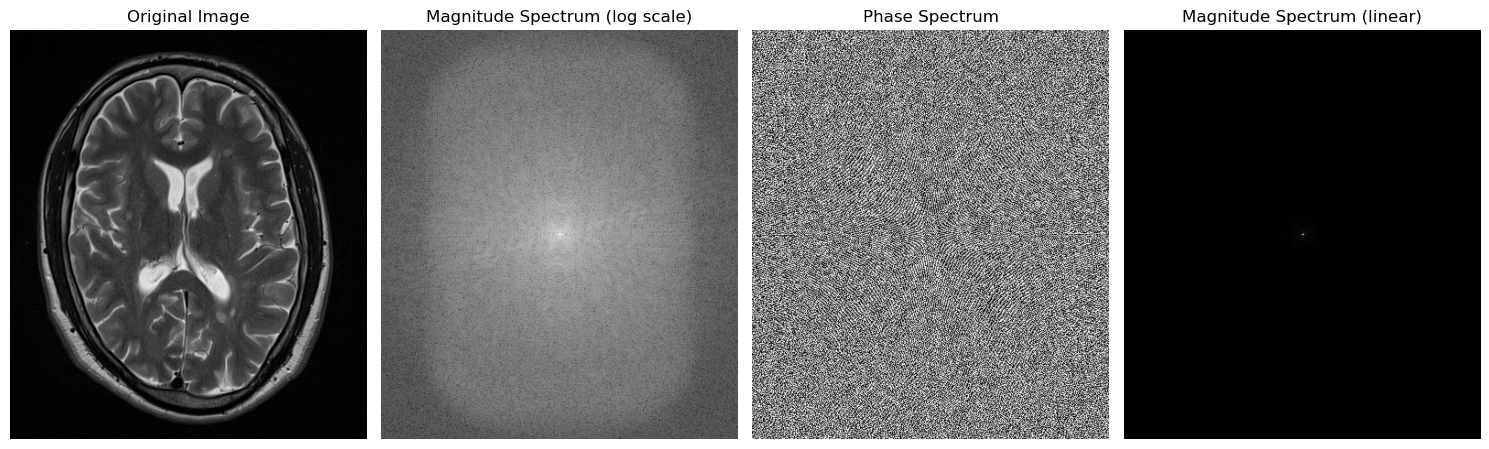

In [6]:
"""
6) Compute Fourier Transform of the image--------------------
"""
img_array = np.array(image, dtype=np.float32)

# Perform 2D FFT
fft_image = np.fft.fft2(img_array)

# Shift zero frequency component to center
fft_shifted = np.fft.fftshift(fft_image)

# Compute magnitude spectrum (absolute values)
magnitude_spectrum = np.abs(fft_shifted)

# Compute phase spectrum
phase_spectrum = np.angle(fft_shifted)

# Convert to logarithmic scale for better visualization
magnitude_log = np.log1p(magnitude_spectrum)  # log(1 + magnitude)

# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(magnitude_log, cmap='gray')
plt.title('Magnitude Spectrum (log scale)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(phase_spectrum, cmap='gray')
plt.title('Phase Spectrum')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum (linear)')
plt.axis('off')

plt.tight_layout()
plt.show()

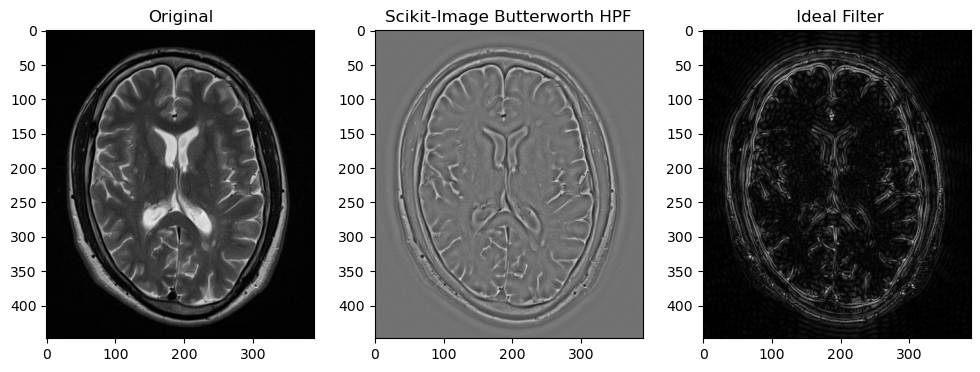

In [7]:
"""
7) Apply high pass filters (Ideal---high pass, High pass Butterworth filter). Show and
discuss the results……---------

"""
from skimage import io, color, filters
import matplotlib.pyplot as plt
from scipy import fftpack

# Apply Butterworth High Pass Filter
# cutoff_frequency_ratio: 0 to 0.5 (fraction of Nyquist frequency)
# high_pass: True for high-pass, False for low-pass
# order: Controls the sharpness of the transition
butter_hpf = filters.butterworth(image, cutoff_frequency_ratio=0.05, 
                                 high_pass=True, order=5)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(image,cmap='gray')
plt.title("Original")
plt.subplot(1,3,2)
plt.imshow(butter_hpf, cmap='gray')
plt.title("Scikit-Image Butterworth HPF")
#plt.show()

def apply_ideal_hpf(image, cutoff):
    # Transform to frequency domain
    f_shift = fftpack.fftshift(fftpack.fft2(image))
    
    # Create the Ideal Mask (Block low frequencies in center)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2
    y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
    mask = (x**2 + y**2) > cutoff**2
    
    # Apply mask and transform back
    f_filtered = f_shift * mask
    img_back = fftpack.ifft2(fftpack.ifftshift(f_filtered))
    return np.abs(img_back)

# Usage
filtered_ideal = apply_ideal_hpf(image, cutoff=30)
plt.subplot(1,3,3)
plt.imshow(filtered_ideal,cmap='gray')
plt.title(" Ideal Filter")
plt.show()


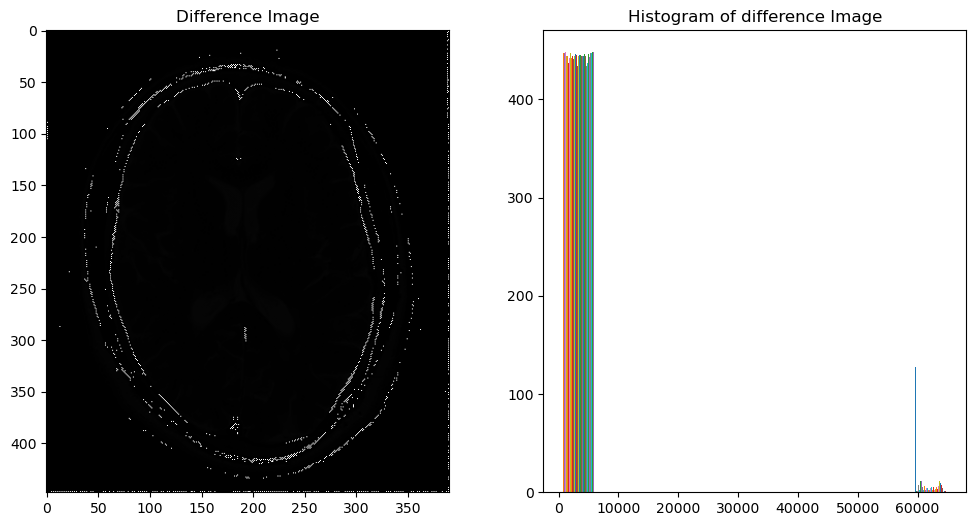

In [14]:
"""
8) Compute the difference image between the original image and filtered image (using mean
filter). Find the histograms of the difference image and discuss the histogram.
"""
filtered = filtered.astype(np.uint16)
img = image.astype(np.uint16)
diff = img - filtered # from question 5
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(diff,cmap='gray')
plt.title("Difference Image")

plt.subplot(1,2,2)
#plt.ylim(0,100)
plt.hist(diff) # ,bins=256)
plt.title("Histogram of difference Image")
plt.show()